# 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Base_de_datos.csv', sep=';', encoding='utf-8-sig')
print("Dimensiones originales:", df.shape)
df.head()

Dimensiones originales: (10763, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,4,7/01/2025 14:40,1852560,12,32,Empleado,3500000,1000000,128650,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,916148.0,Creciente,1
1,4,9/01/2025 11:18,3181080,6,34,Empleado,5000000,2000000,441817,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,4473774.0,Creciente,1
2,9,26/12/2024 18:52,670200,5,34,Independiente,5000000,2000000,108632,"95,227787",...,0.0,274561.0,274561.0,NaN,2,0,1,NaN,NaN,1
3,9,4/12/2024 14:20,506807,2,25,Independiente,3000000,900000,199684,"95,227787",...,0.0,27564.0,27564.0,NaN,1,0,6,NaN,NaN,1
4,4,30/04/2025 18:41,999780,10,26,Empleado,2000000,600000,92509,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,61000.0,Creciente,1


# 2. Exploración inicial de datos

## 2.1 Descripción general y caracterización de datos

In [ ]:
# PENDIENTE: clasificar cada variable como categorica/numerica/ordinal/nominal/dicotomica/politomica


## 2.2 Unificar la forma como se representan los valores Nulos

**Tratamiento de nulos**
Conclusión de negocio: cuando un cliente tiene cant_creditosvigentes = 0 (este crédito es el único que tiene, no hay otros créditos activos), los campos que agregan información de otros créditos simplemente no tienen nada que sumar por ende no es un dato perdido por error, es la ausencia lógica de algo que no existe. El tratamiento correcto aquí no es la mediana (que sugeriría "no sabemos el valor"), sino cero (que dice correctamente "no hay saldo porque no hay otro crédito").

lo tratamos con un 0

In [9]:
# saldo_principal, saldo_mora, saldo_total, saldo_mora_codeudor:
# nulos = ausencia estructural (cliente sin otros creditos / sin codeudor), no error.
# Se imputan con 0, con trazabilidad de qué filas se tocaron.

columnas_saldo = ['saldo_principal', 'saldo_mora', 'saldo_total', 'saldo_mora_codeudor']

for col in columnas_saldo:
    df[f'{col}_era_nulo'] = df[col].isnull()
    df[col] = df[col].fillna(0)

print("Nulos restantes en columnas de saldo:")
print(df[columnas_saldo].isnull().sum())

print("\nVerificación - relación con cant_creditosvigentes=0:")
print(df.groupby(df['saldo_principal_era_nulo'])['cant_creditosvigentes'].median())

Nulos restantes en columnas de saldo:
saldo_principal        0
saldo_mora             0
saldo_total            0
saldo_mora_codeudor    0
dtype: int64

Verificación - relación con cant_creditosvigentes=0:
saldo_principal_era_nulo
False    5.0
True     0.0
Name: cant_creditosvigentes, dtype: float64


se analiza que se hacen con Nulos en promedio_ingresos_datacredito, tendencia_ingresos y puntaje_datacredito

promedio_ingresos_datacredito y tendencia_ingresos (~27% nulos cada uno, prácticamente las mismas filas) Con más de una cuarta parte de los datos ausentes, imputar con la media o mediana sería inventar el 27% de una variable  eso distorsiona cualquier análisis o modelo que la use después.
Es por eso que  aquí la pratica ideeal seria no fabricar el valor: se deja el número como está (NaN) pero creamos una bandera explícita que indique "este dato no está disponible", para que cualquier análisis posterior lo maneje con conocimiento de causa, y agregamos una categoría explícita Sin_dato en la variable categórica
puntaje_datacredito (0.06%, solo 6 registros) imputar con la mediana

In [10]:
# promedio_ingresos_datacredito: alto % de nulos, sin causa estructural clara.
# NO se imputa con un valor inventado; se deja el NaN y se marca con bandera explícita.
df['promedio_ingresos_datacredito_era_nulo'] = df['promedio_ingresos_datacredito'].isnull()

# tendencia_ingresos: mismo caso, se usa categoría explícita "Sin_dato"
# en vez de imputar con la moda (que fabricaría una tendencia que no conocemos).
df['tendencia_ingresos'] = df['tendencia_ingresos'].fillna('Sin_dato')

# puntaje_datacredito: nulos insignificantes (0.06%), se imputa con mediana sin riesgo.
mediana_puntaje_dc = df['puntaje_datacredito'].median()
df['puntaje_datacredito'] = df['puntaje_datacredito'].fillna(mediana_puntaje_dc)

print("Nulos restantes en todo el dataset:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos restantes en todo el dataset:
promedio_ingresos_datacredito    2930
dtype: int64


## 2.3 Eliminación de variables irrelevantes

In [ ]:
# PENDIENTE: evaluar y eliminar columnas irrelevantes para el analisis/modelado


## 2.4 Convertir los datos en su tipo correcto y corrección de los datos

In [2]:
# Corregir 'puntaje': texto con coma decimal -> float
df['puntaje'] = df['puntaje'].str.replace(',', '.').astype(float)

print("Tipo de 'puntaje' después de la conversión:", df['puntaje'].dtype)
print(df['puntaje'].describe())

Tipo de 'puntaje' después de la conversión: float64
count    10763.000000
mean        91.170036
std         16.465441
min        -38.009990
25%         95.227787
50%         95.227787
75%         95.227787
max         95.227787
Name: puntaje, dtype: float64


In [3]:
# Corregir 'fecha_prestamo': texto -> datetime
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'], format='%d/%m/%Y %H:%M', errors='coerce')

print("Tipo de 'fecha_prestamo' después de la conversión:", df['fecha_prestamo'].dtype)
print("Fechas nulas tras la conversión (errores de formato):", df['fecha_prestamo'].isnull().sum())
print("Rango de fechas:", df['fecha_prestamo'].min(), "a", df['fecha_prestamo'].max())

Tipo de 'fecha_prestamo' después de la conversión: datetime64[us]
Fechas nulas tras la conversión (errores de formato): 0
Rango de fechas: 2024-11-26 09:17:00 a 2026-04-26 18:43:00


# atipicos en edad_cliente
Se trata y lo recomendable seriacomo dato faltante (NaN) e imputar debido a que la edad es inválida, no confiable, pero el resto del registro sí lo es. Imputamos con la mediana (robusta a atípicos) y dejamos trazabilidad de qué se imputó.
ademas se crea una columna booleana que marque qué registros fueron corregidos, para no esconder dicha intervencion


In [4]:
# Investigar el patrón de los atípicos de edad antes de decidir
print("Distribución de edades > 80:")
print(df[df['edad_cliente'] > 80]['edad_cliente'].value_counts().sort_index())

Distribución de edades > 80:
edad_cliente
121      4
122    144
123      2
Name: count, dtype: int64


In [5]:
# Umbral de corte: no hay registros entre 70 y 120, así que >90 captura
# limpiamente solo los atípicos (121, 122, 123), sin tocar edades reales
UMBRAL_EDAD = 90

# Trazabilidad establecidad
df['edad_cliente_corregida'] = df['edad_cliente'] > UMBRAL_EDAD

print("Registros marcados para corrección:", df['edad_cliente_corregida'].sum())

# Guarde la mediana calculada SOLO con datos válidos (excluyendo el error)
mediana_edad = df.loc[~df['edad_cliente_corregida'], 'edad_cliente'].median()
print("Mediana de edad (con datos válidos):", mediana_edad)

# Imputar es decir se reemplaza los atípicos por la mediana
df.loc[df['edad_cliente_corregida'], 'edad_cliente'] = mediana_edad

print("\nVerificación después de la corrección:")
print(df['edad_cliente'].describe())

Registros marcados para corrección: 150
Mediana de edad (con datos válidos): 42.0

Verificación después de la corrección:
count    10763.000000
mean        42.833875
std         11.864169
min         19.000000
25%         33.000000
50%         42.000000
75%         52.000000
max         69.000000
Name: edad_cliente, dtype: float64


Hacemos un tratamiento de salario en este caso es necesario
revisar la distribucion que existe ya que el percentil 99 (39.5m)  y el 99.5 (276M)
Se realizar el interquartilico a ver

In [6]:
# Método IQR (Tukey) para detectar atípicos de forma estadísticamente fundamentada
Q1 = df['salario_cliente'].quantile(0.25)
Q3 = df['salario_cliente'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

print(f"Q1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f}")
print(f"Límite superior (Q3 + 1.5*IQR): {limite_superior:,.0f}")
print(f"Límite inferior: {limite_inferior:,.0f}")

print(f"\nRegistros por encima del límite superior: {(df['salario_cliente'] > limite_superior).sum()}")
print(f"Registros con salario = 0: {(df['salario_cliente'] == 0).sum()}")

Q1: 2,000,000 | Q3: 4,875,808 | IQR: 2,875,808
Límite superior (Q3 + 1.5*IQR): 9,189,520
Límite inferior: -2,313,712

Registros por encima del límite superior: 718
Registros con salario = 0: 24


entonces tenemos que variables monetarias así de sesgadas es ideal aplicar el IQR sobre la escala logarítmica (transformación log), que nos comprime la cola larga y hace que el método funcione correctamente.

In [7]:
# El IQR sobre escala original sobre-marca salarios altos pero legítimos
# (la distribución de salario es naturalmente asimétrica). Usamos log-transform,
# técnica estándar para variables monetarias sesgadas, antes de aplicar IQR.

# Separamos los ceros (se tratan aparte, no tiene sentido incluirlos en el log)
mask_valido = df['salario_cliente'] > 0
log_salario = np.log(df.loc[mask_valido, 'salario_cliente'])

Q1_log = log_salario.quantile(0.25)
Q3_log = log_salario.quantile(0.75)
IQR_log = Q3_log - Q1_log
limite_superior_log = Q3_log + 1.5 * IQR_log
limite_superior = np.exp(limite_superior_log)

print(f"Límite superior (log-IQR): {limite_superior:,.0f}")

# Trazabilidad: marcar filas corregidas (salario=0 O por encima del límite)
df['salario_cliente_corregido'] = (df['salario_cliente'] == 0) | (df['salario_cliente'] > limite_superior)

print("Registros marcados para corrección:", df['salario_cliente_corregido'].sum())

# Mediana calculada solo con datos válidos (ni ceros ni atípicos)
mediana_salario = df.loc[~df['salario_cliente_corregido'], 'salario_cliente'].median()
print("Mediana de salario (datos válidos):", f"{mediana_salario:,.0f}")

# Imputar
df.loc[df['salario_cliente_corregido'], 'salario_cliente'] = mediana_salario

print("\nVerificación después de la corrección:")
print(df['salario_cliente'].describe())

Límite superior (log-IQR): 18,790,797
Registros marcados para corrección: 250
Mediana de salario (datos válidos): 3,000,000

Verificación después de la corrección:
count    1.076300e+04
mean     3.650006e+06
std      2.546061e+06
min      1.000000e+03
25%      2.000000e+06
50%      3.000000e+06
75%      4.500000e+06
max      1.875657e+07
Name: salario_cliente, dtype: float64


## Limpieza — Atípicos edad_cliente y salario_cliente

- **edad_cliente**: 150 registros con valores imposibles (121-123 años) detectados por salto claro en la distribución (sin datos entre 70 y 120). Imputados con la mediana (42 años) de los datos válidos. Trazabilidad en `edad_cliente_corregida`.
- **salario_cliente**: el método IQR estándar mostraba salarios altos pero legítimos (6.7% de los datos) por la asimetría natural de la variable. Se aplica IQR sobre escala logarítmica , resultando en un límite de $18.79M y 250 registros corregidos (226 atípicos altos + 24 en cero). Imputados con la mediana ($3M) de los datos válidos. Trazabilidad en `salario_cliente_corregido`.
- **Hallazgo duda : el nuevo mínimo tras la corrección es $1.000 — no cumple los criterios de corrección definidos (no es cero, no supera el límite superior), pero no es un salario mensual creíble. Se deja documentado para una futura revisión de reglas de negocio más finas.


# correcion de tendencias de ingresos
Existe y se evidencia que los 58 registros corruptos tienen promedio_ingresos_datacredito poblado al 100% — no es coincidencia.
Los valores corruptos incluyen números positivos, negativos y ceros (ej. 8315, -224714, 0).
teoria y es que :
probablemente se calculaba originalmente como un valor numérico de variación de ingresos (positivo = creció, negativo = decreció, cero = estable), y luego un proceso automático lo convertía a categoría (Creciente/Decreciente/Estable). Para estos 58 registros, esa conversión falló y quedó el número crudo sin categorizar

Decision tomada : Reconstruir datos es decir la categoría usando el signo del número , no una invención: si el patrón de las categorías reales (Creciente, Decreciente, Estable) 

In [8]:
categorias_validas = {'Creciente', 'Decreciente', 'Estable'}
mask_corrupto = df['tendencia_ingresos'].notna() & ~df['tendencia_ingresos'].isin(categorias_validas)

print("Registros corruptos detectados:", mask_corrupto.sum())

# Reconstrucción basada en el signo del valor numérico (supuesto documentado:
# tendencia_ingresos originalmente representaba variación numérica de ingresos)
valores_numericos = pd.to_numeric(df.loc[mask_corrupto, 'tendencia_ingresos'], errors='coerce')

def clasificar_tendencia(v):
    if v > 0:
        return 'Creciente'
    elif v < 0:
        return 'Decreciente'
    else:
        return 'Estable'

# Trazabilidad
df['tendencia_ingresos_reconstruida'] = mask_corrupto

# Reconstrucción
df.loc[mask_corrupto, 'tendencia_ingresos'] = valores_numericos.apply(clasificar_tendencia)

print("\nDistribución final de 'tendencia_ingresos':")
print(df['tendencia_ingresos'].value_counts(dropna=False))

Registros corruptos detectados: 58

Distribución final de 'tendencia_ingresos':
tendencia_ingresos
Creciente      5335
NaN            2932
Decreciente    1301
Estable        1195
Name: count, dtype: int64


Creciente subió de 5294→5335, Decreciente de 1291→1301, Estable de 1188→1195; suman los 58), y los 2.932 NaN

## Limpieza — tendencia_ingresos (valores corruptos)

- Se detectaron 58 registros con valores numéricos en vez de categoría, y el 100% de ellos tenía `promedio_ingresos_datacredito` poblado — indicio de que `tendencia_ingresos` se derivaba originalmente de un valor numérico de variación de ingresos, y el proceso de categorización falló para estos casos.
- **Reconstrucción aplicada**: se clasificó cada valor corrupto según su signo (positivo → Creciente, negativo → Decreciente, cero → Estable), replicando la lógica de negocio esperada en vez de descartar la información.
- Trazabilidad en la columna `tendencia_ingresos_reconstruida`.
- Los 2.932 valores nulos originales (27.24%) aun no se modifico en este paso entonces se tratarán en el paso de nulos junto con las demás columnas.

# 3. Exploración de datos y descripción (EDA)

## 3.1 Análisis univariado

In [3]:
# Duplicados
print("Filas duplicadas exactas:", df.duplicated().sum())

# Nulos por columna
print("\nValores nulos por columna:")
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje': nulos_pct})
print(resumen_nulos[resumen_nulos['nulos'] > 0])

# Revisión de la columna 'puntaje' (debería ser numérica, llega como texto)
print("\nTipo de 'puntaje':", df['puntaje'].dtype)
print("Ejemplos:", df['puntaje'].unique()[:5])

# Revisión de 'tendencia_ingresos' (debería tener solo 3 categorías)
print("\nValores únicos en 'tendencia_ingresos':")
print(df['tendencia_ingresos'].value_counts())

Filas duplicadas exactas: 0

Valores nulos por columna:
                               nulos  porcentaje
puntaje_datacredito                6        0.06
saldo_mora                       156        1.45
saldo_total                      156        1.45
saldo_principal                  405        3.76
saldo_mora_codeudor              590        5.48
promedio_ingresos_datacredito   2930       27.22
tendencia_ingresos              2932       27.24

Tipo de 'puntaje': str
Ejemplos: <StringArray>
['95,227787', '86,830187', '18,451409', '47,613894', '28,340846']
Length: 5, dtype: str

Valores únicos en 'tendencia_ingresos':
tendencia_ingresos
Creciente      5294
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031          

## Hallazgos — Calidad de datos

- **Duplicados**: 0 filas duplicadas
- **Nulos relevantes**:
  - `promedio_ingresos_datacredito` (27.22%) y `tendencia_ingresos` (27.24%): alto porcentaje de nulos
  - `saldo_mora_codeudor` (5.48%), `saldo_principal` (3.76%), `saldo_mora`/`saldo_total` (1.45%): nulos menores, posiblemente créditos sin codeudor o sin saldo registrado.
  - `puntaje_datacredito` (0.06%): nulos mínimos detectados
- **`puntaje` mal formateado**: está almacenada como texto (`str`) con coma decimal (ej. `'95,227787'`) en vez de número.entonces debe convertirse a `float` reemplazando la coma por punto.
- **`tendencia_ingresos` corrupta**: además de las 3 categorías esperadas (`Creciente`, `Decreciente`, `Estable`), existen valores numéricos sueltos (ej. `8315`, `1000000`, `-224714`) que no corresponden a una categoría válida — indica un problema de origen en los datos como tal

In [4]:
# Atípicos en edad
print("=== Edad ===")
print(df['edad_cliente'].describe())
print("\nRegistros con edad > 90:")
print(df[df['edad_cliente'] > 90]['edad_cliente'].value_counts())

# Atípicos en salario
print("\n=== Salario ===")
print(df['salario_cliente'].describe())
print("\nRegistros con salario en cero:", (df['salario_cliente'] == 0).sum())
print("Registros con salario > 50,000,000:", (df['salario_cliente'] > 50_000_000).sum())
print("\nTop 10 salarios más altos:")
print(df['salario_cliente'].sort_values(ascending=False).head(10))

=== Edad ===
count    10763.000000
mean        43.948620
std         15.060877
min         19.000000
25%         33.000000
50%         42.000000
75%         53.000000
max        123.000000
Name: edad_cliente, dtype: float64

Registros con edad > 90:
edad_cliente
122    144
121      4
123      2
Name: count, dtype: int64

=== Salario ===
count    1.076300e+04
mean     1.721643e+07
std      3.554767e+08
min      0.000000e+00
25%      2.000000e+06
50%      3.000000e+06
75%      4.875808e+06
max      2.200000e+10
Name: salario_cliente, dtype: float64

Registros con salario en cero: 24
Registros con salario > 50,000,000: 97

Top 10 salarios más altos:
5515     22000000000
2737     16991100000
10476    13258352050
10505    12450806583
10503     8252584000
10532     7170914725
10515     4857353453
10578     4663274549
10572     4067140000
10520     3979311000
Name: salario_cliente, dtype: int64


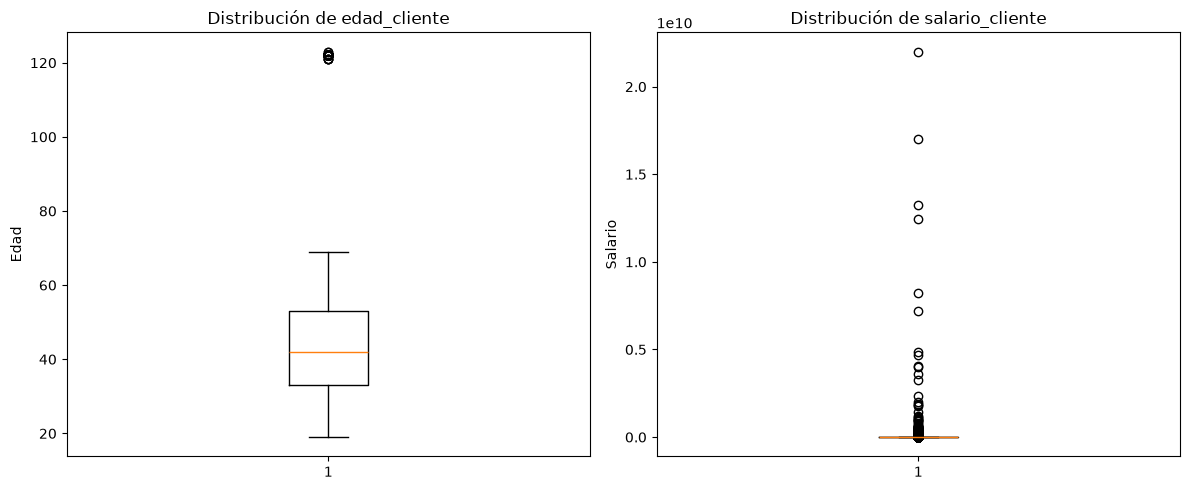

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['edad_cliente'].dropna())
axes[0].set_title('Distribución de edad_cliente')
axes[0].set_ylabel('Edad')

axes[1].boxplot(df['salario_cliente'].dropna())
axes[1].set_title('Distribución de salario_cliente')
axes[1].set_ylabel('Salario')

plt.tight_layout()
plt.show()

## Hallazgos — Atípicos

- **Edad**: 150 registros (1.4%) con edad entre 121 y 123 años — valor imposible, probablemente  error o valor capturado por el sistema de originación. El resto de la distribución es coherente (min 19, max real ~68-70, mediana 42).
- **Salario**: distribución extremadamente asimétrica. La mediana es de ~$3.000.000, pero existen 97 registros con salario > $50.000.000 mensuales, llegando hasta $22.000 millones — no son creíbles como ingreso mensual real. Posible error de digitación (dígitos de más) o mezcla de unidades (ej. salario anual capturado como mensual).
- Ambos casos se trataran en la fase de limpieza.

In [ ]:
# PENDIENTE: describe() completo, histogramas y countplots para TODAS las variables, medidas de dispersion (IQR, varianza, desviacion estandar, skewness, kurtosis), tipo de distribucion


## 3.2 Análisis bivariado

In [6]:
# analisis vibariado variables vs pago_atiempo
# Comparación de variables numéricas clave entre clientes al día vs en mora
variables_clave = ['edad_cliente', 'salario_cliente', 'capital_prestado', 
                    'plazo_meses', 'cuota_pactada', 'cant_creditosvigentes', 
                    'huella_consulta', 'puntaje_datacredito']

comparacion = df.groupby('Pago_atiempo')[variables_clave].median()
print("Mediana por grupo (0 = mora, 1 = al día):")
print(comparacion)

Mediana por grupo (0 = mora, 1 = al día):
              edad_cliente  salario_cliente  capital_prestado  plazo_meses  \
Pago_atiempo                                                                 
0                     38.0        3000000.0         2268000.0         10.0   
1                     42.0        3000000.0         1908446.5         10.0   

              cuota_pactada  cant_creditosvigentes  huella_consulta  \
Pago_atiempo                                                          
0                  199002.0                    5.0              5.0   
1                  182576.0                    5.0              4.0   

              puntaje_datacredito  
Pago_atiempo                       
0                           768.0  
1                           792.0  


In [ ]:
# PENDIENTE: graficos bivariados (no solo tablas) de variables clave vs Pago_atiempo


In [7]:
# tasa de morosidad por segmento categorico
tasa_laboral = df.groupby('tipo_laboral')['Pago_atiempo'].agg(['mean', 'count'])
tasa_laboral['tasa_mora_%'] = ((1 - tasa_laboral['mean']) * 100).round(2)
print(tasa_laboral[['count', 'tasa_mora_%']])

# Tasa de mora por tipo de crédito
tasa_credito = df.groupby('tipo_credito')['Pago_atiempo'].agg(['mean', 'count'])
tasa_credito['tasa_mora_%'] = ((1 - tasa_credito['mean']) * 100).round(2)
print(tasa_credito[['count', 'tasa_mora_%']].sort_values('tasa_mora_%', ascending=False))

               count  tasa_mora_%
tipo_laboral                     
Empleado        6754         4.29
Independiente   4009         5.51
              count  tasa_mora_%
tipo_credito                    
6                21        42.86
9              2876         4.73
4              7747         4.69
10              116         2.59
7                 2         0.00
68                1         0.00


## Hallazgos — Segmentación categórica

- **tipo_laboral**: los independientes tienen una tasa de mora ligeramente mayor que los empleados (5.51% vs 4.29%), consistente con mayor variabilidad de ingresos.
- **tipo_credito**: el tipo de crédito **6** muestra una tasa de mora de **42.86%**, muy por encima del resto (~4-5%). Con solo 21 registros, la muestra es pequeña y se necesita más data  qué represente este tipo de crédito para sacar conclusiones como tal definitivas, pero es una señal de alerta fuerte a
- Los tipos 7 y 68 muestran 0% de mora, pero con 1-2 registros cada uno — no son representativos, se excluyen de conclusiones.

## 3.3 Análisis multivariado

In [ ]:
# PENDIENTE: pairplot, matriz de correlacion, graficos de dispersion con parametro hue, tablas cruzadas


# 4. Reglas de validación de datos

In [ ]:
# PENDIENTE: documentar reglas de validacion para usar en etapas posteriores (ej. rango valido de edad, salario, etc.)


# 5. Identificación del atributo objetivo (target)

In [ ]:
# PENDIENTE: declarar explicitamente Pago_atiempo como variable objetivo y justificar


# 6. Transformaciones futuras aplicables

In [ ]:
# PENDIENTE: identificar transformaciones utiles para modelado (encoding, escalado, etc.)


# 7. Atributos adicionales (derivados/calculados) — MUY IMPORTANTE

In [ ]:
# PENDIENTE: identificar posibles variables derivadas/calculadas de valor para el negocio o el modelo


# 8. Conclusiones e insights de negocio

## Conclusiones e Insights de Negocio

1. **Calidad de datos**: la columna `puntaje` está mal formateada (texto con coma decimal), `tendencia_ingresos` tiene ~2.9% de registros corruptos, y existen valores imposibles en edad (150 registros) y salario (97 registros) que deben tratarse.

2. **El desbalance de clases es alto**: solo 4.75% de los créditos caen en mora. Cualquier análisis o modelo debe considerar este desbalance para no sesgar conclusiones.

3. **Perfil de mayor riesgo**: clientes más jóvenes, con montos de capital prestado y cuotas más altas, mayor número de consultas recientes a central de riesgo (huella_consulta), y menor puntaje Datacrédito muestran más propensión a caer en mora.

4. **Tipo de crédito como señal de alerta**: el tipo de crédito 6 tiene una tasa de mora casi 10x mayor que el promedio (42.86% vs ~4.75%), aunque con muestra pequeña entonces amerita i ver y hacer una nvestigación prioritaria para el negocio.

5. **Independientes vs. Empleados**: los independientes muestran mayor tasa de mora, coherente con la mayor variabilidad de ingresos de este segmento.

limpiar y transformar las variables identificadas (Fase 1 - ETL), e investigar con mayor profundidad el tipo de crédito 6 y la relación huella_consulta / mora.

# 9. Verificación final y guardado del dataset limpio

buenas praticas de analista se plantea hacer:
verificacion que no quedaron duplicados ni nulos inesperados después de todas las transformaciones.
guardar el dataset limpio en un nuevo archivo
documentacion final

In [11]:
print("Dimensiones finales:", df.shape)
print("Duplicados:", df.duplicated().sum())
print("\nNulos restantes (deben ser solo promedio_ingresos_datacredito, de forma intencional):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dimensiones finales: (10763, 31)
Duplicados: 0

Nulos restantes (deben ser solo promedio_ingresos_datacredito, de forma intencional):
promedio_ingresos_datacredito    2930
dtype: int64


In [12]:

# Guardamos en un archivo NUEVO para no sobrescribir el dato crudo original.
# Esto preserva la trazabilidad: siempre se puede volver a Base_de_datos.csv
# y reproducir todo el proceso de limpieza desde cero si es necesario.
df.to_csv('../Base_de_datos_limpia.csv', sep=';', index=False, encoding='utf-8-sig')
print("Archivo guardado: Base_de_datos_limpia.csv")
print("Columnas finales:", df.shape[1])

Archivo guardado: Base_de_datos_limpia.csv
Columnas finales: 31


## Resumen — Fase 1 (ETL) completada

Transformaciones aplicadas sobre `Base_de_datos.csv`, resultado guardado en `Base_de_datos_limpia.csv`:

1. **Tipos de dato corregidos**: `puntaje` (texto→float), `fecha_prestamo` (texto→datetime)
2. **Atípicos de `edad_cliente`**: 150 registros (121-123 años) imputados con la mediana (42), detectados por saltos  claro en la distribución
3. **Atípicos de `salario_cliente`**: 250 registros corregidos usando IQR sobre escala logarítmica (técnica adecuada para variables monetarias asimétricas), imputados con la mediana ($3M)
4. **`tendencia_ingresos` corrupta**: 58 registros reconstruidos por signo numérico (supuesto documentado sobre el origen del dato)
5. **Nulos estructurales** (`saldo_principal`, `saldo_mora`, `saldo_total`, `saldo_mora_codeudor`): imputados con 0, la causa (ausencia de otros créditos activos)
6. **Nulos de `puntaje_datacredito`**: imputados con mediana (impacto insignificante, 0.06%)
7. **Nulos de `promedio_ingresos_datacredito` y `tendencia_ingresos`**: dejados como NaN/`Sin_dato` de forma intencional (27% de los datos, sin causa estructural identificada, decisión diferida a la fase de modelado)

Todas las columnas modificadas tienen su respectiva columna de trazabilidad (`*_corregida`, `*_era_nulo`, `*_reconstruida`) para auditoría.